#  Filtro Bayer y Transformaciones YUV

---

## Filtro Bayer

### ¿Qué es el filtro Bayer?
El **filtro de color Bayer** (también llamado *Bayer CFA* o *Bayer mosaic*) es una matriz de microfiltros de color que se coloca directamente sobre el sensor de imagen de una cámara digital. Fue inventado por **Bryce Bayer**, ingeniero de Eastman Kodak, y patentado en **1976**. Hoy en día sigue siendo el estándar más utilizado en la industria fotográfica y de visión por computadora.

---

### ¿De dónde proviene?
Los sensores de imagen digitales (tanto CCD como CMOS) son dispositivos fotosensibles que únicamente pueden medir la **intensidad de la luz**, es decir, producen imágenes en escala de grises. Para poder capturar color, Bayer propuso colocar un filtro de color sobre cada píxel del sensor, de modo que cada píxel solo reciba luz de un color (Rojo, Verde o Azul).

El resultado crudo del sensor antes de ser procesado se conoce como imagen **RAW** o **datos Bayer**. Esta imagen parece estar en escala de grises con un ligero mosaico de colores, y requiere un procesamiento posterior para generar una imagen RGB completa.

---

### ¿Por qué se usa más verde (patrón RGGB)?
El patrón más común es **RGGB**, donde el 50% de los píxeles son verdes, 25% rojos y 25% azules. Esto se debe a que:
- El ojo humano es **más sensible al verde** que a cualquier otro color.
- El verde representa mejor el **brillo y la luminancia** percibida.
- Usar el doble de píxeles verdes mejora la nitidez y reduce el ruido visual.

El patrón se repite en bloques de 2x2 píxeles:
```
R  G  R  G  ...
G  B  G  B  ...
R  G  R  G  ...
G  B  G  B  ...
```

---

### ¿Qué es el demosaicing?
Como cada píxel solo tiene información de UN color, los otros dos colores deben ser **estimados (interpolados)** a partir de los píxeles vecinos. Este proceso se llama **demosaicing** (o desmosaicado). Existen varios algoritmos para hacerlo, desde interpolación bilineal simple hasta métodos adaptativos más avanzados. OpenCV implementa versiones básicas pero eficientes.

---

### Versiones del filtro Bayer en OpenCV (cv2)
OpenCV ofrece **4 variantes** del filtro Bayer, diferenciadas por el orden del patrón en la esquina superior izquierda del sensor:

| Código cv2 | Patrón | Descripción |
|---|---|---|
| `COLOR_BayerBG2BGR` | BG | El píxel [0,0] es Azul, [0,1] es Verde |
| `COLOR_BayerGB2BGR` | GB | El píxel [0,0] es Verde, [0,1] es Azul |
| `COLOR_BayerRG2BGR` | RG | El píxel [0,0] es Rojo, [0,1] es Verde *(RGGB, el más común)* |
| `COLOR_BayerGR2BGR` | GR | El píxel [0,0] es Verde, [0,1] es Rojo |

Cada variante produce una imagen con diferente dominancia de color según cómo interpreta el mosaico inicial.

---

### Aplicaciones del filtro Bayer
- **Fotografía digital**: todas las cámaras con sensor CMOS o CCD usan este filtro.
- **Visión por computadora**: procesamiento de imágenes RAW industriales y científicas.
- **Astronomía**: algunas cámaras astronómicas usan patrones Bayer para capturar color.
- **Medicina**: cámaras endoscópicas y microscopios digitales.


In [ ]:
# Listar versiones del filtro Bayer disponibles en cv2
import cv2

bayer_codes = {name: getattr(cv2, name) for name in dir(cv2) if 'Bayer' in name and 'BGR' in name}

print("Versiones de filtro Bayer en cv2:\n")
for name, code in sorted(bayer_codes.items()):
    print(f"  cv2.{name} = {code}")


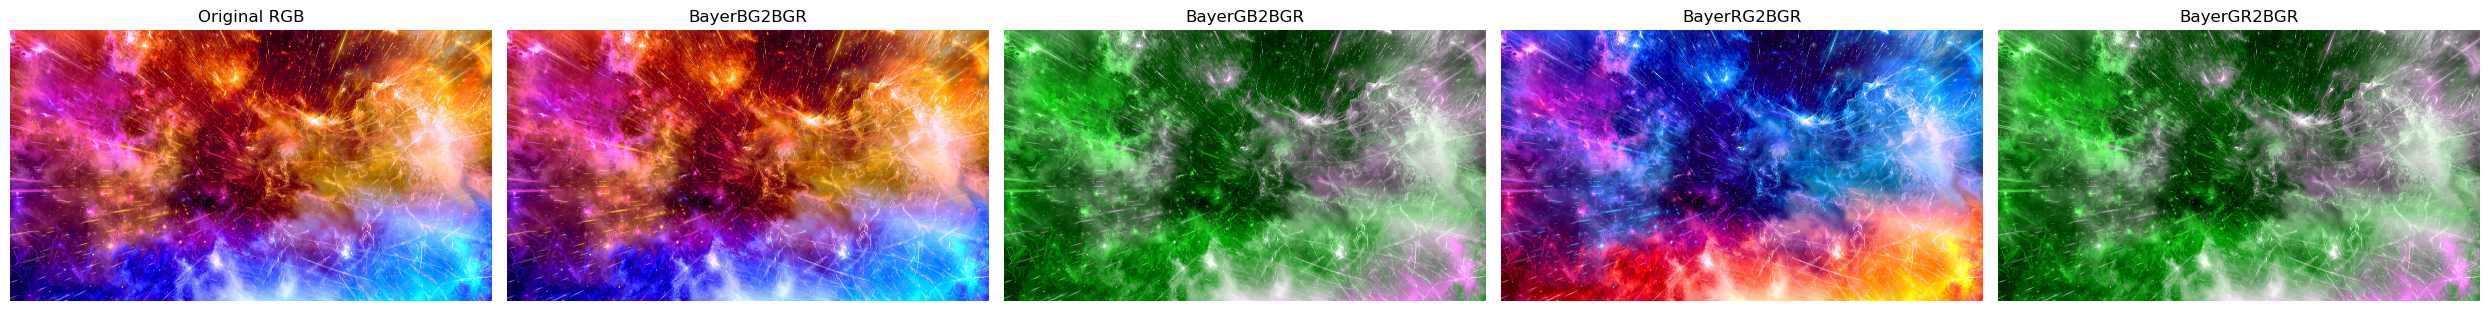

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img_bgr = cv2.imread('colores_nuevo.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Simular patrón Bayer (RGGB) extrayendo canales por bloques 2x2
bayer = np.zeros((img_rgb.shape[0], img_rgb.shape[1]), dtype=np.uint8)
bayer[0::2, 0::2] = img_rgb[0::2, 0::2, 0]  # R
bayer[0::2, 1::2] = img_rgb[0::2, 1::2, 1]  # G
bayer[1::2, 0::2] = img_rgb[1::2, 0::2, 1]  # G
bayer[1::2, 1::2] = img_rgb[1::2, 1::2, 2]  # B

# Aplicamos las 4 versiones de demosaicing Bayer
bayer_bg = cv2.cvtColor(bayer, cv2.COLOR_BayerBG2BGR)
bayer_gb = cv2.cvtColor(bayer, cv2.COLOR_BayerGB2BGR)
bayer_rg = cv2.cvtColor(bayer, cv2.COLOR_BayerRG2BGR)
bayer_gr = cv2.cvtColor(bayer, cv2.COLOR_BayerGR2BGR)

fig, axs = plt.subplots(1, 5, figsize=(25, 5))

axs[0].imshow(img_rgb)
axs[0].set_title('Original RGB')
axs[0].axis('off')

axs[1].imshow(cv2.cvtColor(bayer_bg, cv2.COLOR_BGR2RGB))
axs[1].set_title('BayerBG2BGR')
axs[1].axis('off')

axs[2].imshow(cv2.cvtColor(bayer_gb, cv2.COLOR_BGR2RGB))
axs[2].set_title('BayerGB2BGR')
axs[2].axis('off')

axs[3].imshow(cv2.cvtColor(bayer_rg, cv2.COLOR_BGR2RGB))
axs[3].set_title('BayerRG2BGR')
axs[3].axis('off')

axs[4].imshow(cv2.cvtColor(bayer_gr, cv2.COLOR_BGR2RGB))
axs[4].set_title('BayerGR2BGR')
axs[4].axis('off')

plt.tight_layout()
plt.show()


---

##  Transformaciones YUV ↔ RGB

### ¿Qué es el espacio de color YUV?
**YUV** es un modelo de representación de color que **separa la información de brillo (luminancia) de la información de color (crominancia)**. Fue desarrollado originalmente para la transmisión de televisión analógica en color, con el objetivo de mantener compatibilidad con receptores en blanco y negro.

Sus tres componentes son:
- **Y** (Luminancia): representa el brillo del píxel. Si se extrae solo este canal, se obtiene la imagen en escala de grises.
- **U** (Crominancia azul): diferencia entre el azul y la luminancia → `U = Azul - Y`
- **V** (Crominancia rojo): diferencia entre el rojo y la luminancia → `V = Rojo - Y`

---

### ¿Por qué se usa YUV?
El sistema visual humano es **mucho más sensible a los cambios de brillo** que a los cambios de color. Esto hace que YUV sea ideal para:

- **Compresión de imágenes y video**: formatos como JPEG y MPEG aprovechan que se puede reducir la resolución de los canales U y V (color) sin que el ojo lo note mucho, mientras se mantiene alta resolución en Y (brillo).
- **Transmisión de video**: en televisión analógica y digital, separar Y de UV permite adaptar la señal para pantallas en blanco y negro o color.
- **Procesamiento de imágenes**: trabajar en YUV facilita operaciones como detección de piel, segmentación por color, y ajuste de brillo sin alterar los colores.

---

### Fórmulas de conversión RGB → YUV
La conversión sigue estas ecuaciones estándar:

```
Y =  0.299·R + 0.587·G + 0.114·B
U = -0.147·R - 0.289·G + 0.436·B
V =  0.615·R - 0.515·G - 0.100·B
```

Y la conversión inversa YUV → RGB:
```
R = Y + 1.140·V
G = Y - 0.395·U - 0.581·V
B = Y + 2.032·U
```

OpenCV aplica estas fórmulas internamente con `cv2.COLOR_RGB2YUV` y `cv2.COLOR_YUV2RGB`.

---

### ¿Es reversible la conversión?
Sí. La conversión RGB ↔ YUV es **completamente reversible** (sin pérdida de información). Si se convierte una imagen de RGB a YUV y luego de YUV a RGB, la imagen resultante es idéntica a la original. La pérdida solo ocurre si se modifica o comprime alguno de los canales Y, U o V.

---

### Diferencia entre YUV y otros espacios de color

| Espacio | Separación brillo/color | Uso principal |
|---|---|---|
| RGB | No | Pantallas, captura directa |
| HSV | Parcial | Segmentación por color |
| **YUV** | **Sí** | **Compresión de video/imagen** |
| LAB | Sí | Procesamiento perceptual |


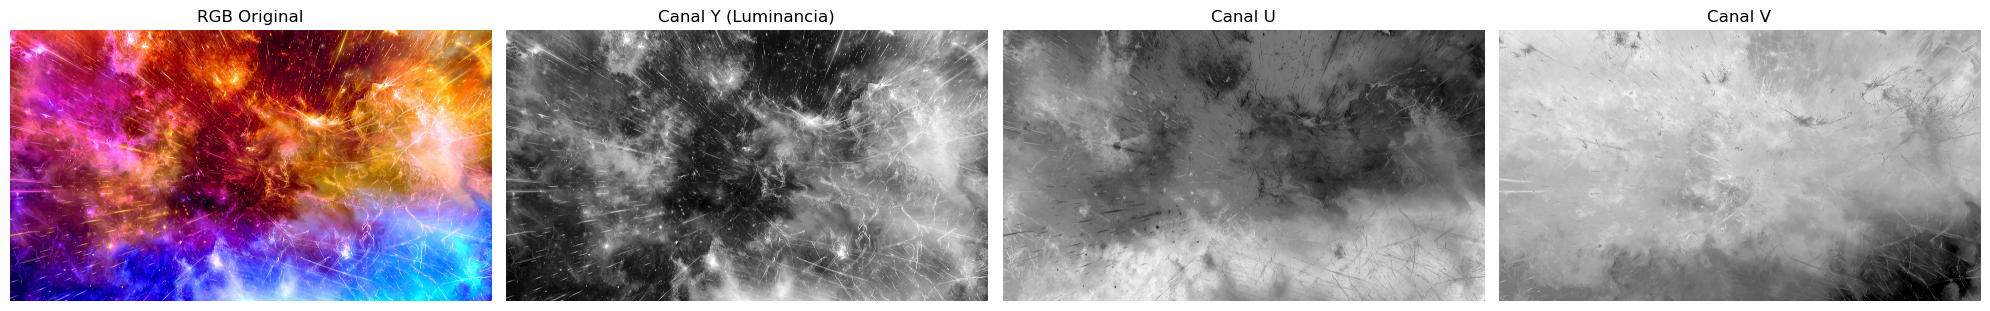

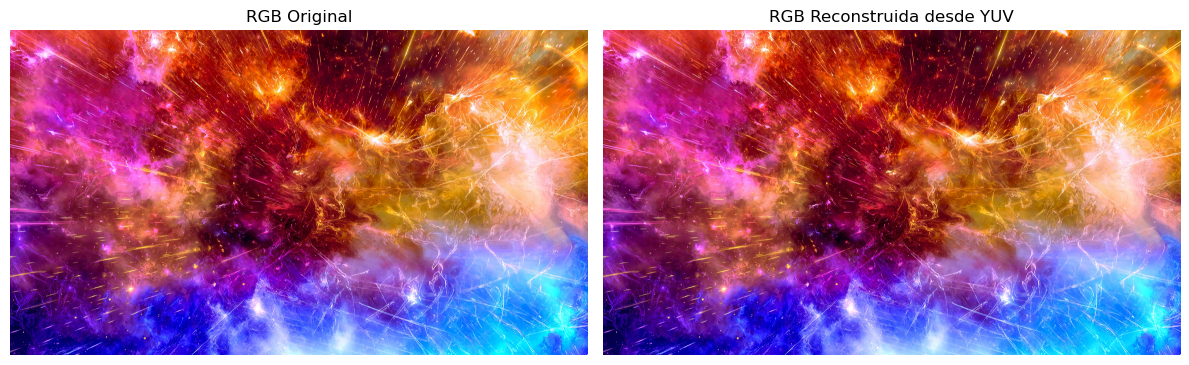

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img_bgr = cv2.imread('colores_nuevo.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# RGB → YUV
img_yuv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YUV)

# YUV → RGB (reconstruida)
img_rgb_reconst = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

# Canales YUV
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

axs[0].imshow(img_rgb)
axs[0].set_title('RGB Original')
axs[0].axis('off')

axs[1].imshow(img_yuv[..., 0], cmap='gray')
axs[1].set_title('Canal Y (Luminancia)')
axs[1].axis('off')

axs[2].imshow(img_yuv[..., 1], cmap='gray')
axs[2].set_title('Canal U')
axs[2].axis('off')

axs[3].imshow(img_yuv[..., 2], cmap='gray')
axs[3].set_title('Canal V')
axs[3].axis('off')

plt.tight_layout()
plt.show()

# Mostrar comparacion original vs reconstruida
fig2, axs2 = plt.subplots(1, 2, figsize=(12, 5))

axs2[0].imshow(img_rgb)
axs2[0].set_title('RGB Original')
axs2[0].axis('off')

axs2[1].imshow(img_rgb_reconst)
axs2[1].set_title('RGB Reconstruida desde YUV')
axs2[1].axis('off')

plt.tight_layout()
plt.show()
